# Notebook 01 — Descarga del grafo vial de Chapinero

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PLACE = 'Chapinero, Bogotá, Colombia'
NETWORK_TYPE = 'drive'

ox.settings.timeout = 120
ox.settings.log_console = True

print(f'Descargando grafo vial para: {PLACE}')
G = ox.graph_from_place(PLACE, network_type=NETWORK_TYPE)
print(f'Nodos : {G.number_of_nodes():,}')
print(f'Aristas: {G.number_of_edges():,}')

Descargando grafo vial para: Chapinero, Bogotá, Colombia
Nodos : 1,821
Aristas: 3,670


In [2]:
nodes, edges = ox.graph_to_gdfs(G)
display(nodes.head())
display(edges[['name','length','highway','oneway','maxspeed']].head())

,y,x,street_count,highway,geometry
osmid,,,,,
253761879,4.671448,-74.057951,3,NaN,POINT (-74.05795 4.67145)
253761882,4.664463,-74.057286,3,NaN,POINT (-74.05729 4.66446)
253761969,4.659440,-74.052285,5,traffic_signals,POINT (-74.05228 4.65944)
253761979,4.673795,-74.056813,3,NaN,POINT (-74.05681 4.67379)
253761997,4.664031,-74.056604,4,NaN,POINT (-74.0566 4.66403)


name      length      highway  \
u         v          key                                                     
253761879 9644335932 0           Avenida Calle 85   17.191568    secondary   
          253762005  0    [Calle 86, Carrera 19A]  195.089037  residential   
253761882 253762016  0                 Carrera 14  101.025944     tertiary   
253761969 7989874686 0                   Calle 77   12.253162     tertiary   
          3197009590 0                   Calle 77   12.641424     tertiary   

                          oneway maxspeed  
u         v          key                   
253761879 9644335932 0      True      NaN  
          253762005  0     False      NaN  
253761882 253762016  0      True       30  
253761969 7989874686 0      True      NaN  
          3197009590 0      True      NaN

In [3]:
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)
print('Velocidades añadidas.')

Velocidades añadidas.


In [4]:
CAPACITY_MAP = {'motorway':2200,'trunk':1800,'primary':1500,'secondary':1200,'tertiary':900,'residential':600,'unclassified':600,'living_street':300,'service':300}

def get_capacity(highway):
    if isinstance(highway, list): highway = highway[0]
    return CAPACITY_MAP.get(highway, 600)

for u, v, k, data in G.edges(data=True, keys=True):
    data['capacity'] = get_capacity(data.get('highway','residential'))
    data['t0'] = data.get('travel_time', 60)
print('Capacidades añadidas.')

Capacidades añadidas.


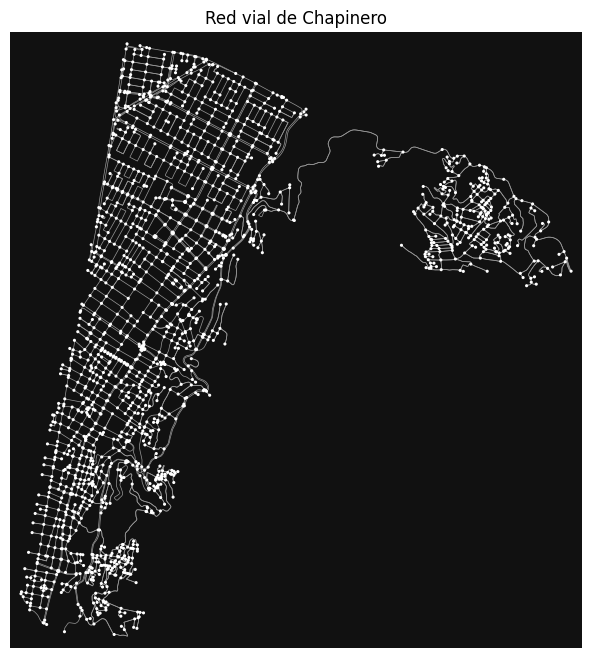

In [5]:
fig, ax = ox.plot_graph(G, node_size=5, edge_linewidth=0.5, show=False, close=False)
plt.title('Red vial de Chapinero')
plt.savefig('../data/raw/chapinero_red_vial.png', dpi=150)
plt.show()

In [6]:
ox.save_graphml(G, '../data/raw/chapinero_drive_enriched.graphml')
print('Grafo guardado.')

Grafo guardado.
